# Import Required Libraries
Import the necessary libraries, including pandas for data manipulation and matplotlib for plotting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data from CSV File
Use pandas to read the ah.csv file into a DataFrame.

In [2]:
df = pd.read_csv('ah.csv')
print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (13, 2)


# Explore the Dataset
Display the first few rows of the dataset and check the data types to understand the structure.

In [3]:
print("First few rows:")
print(df.head())
print("\nData info:")
print(df.info())

First few rows:
         vah        ah
0 -91.095744  0.266420
1 -78.972096  0.176460
2 -76.277952  0.117640
3 -76.446336  0.112450
4 -67.353600  0.116775

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   vah     13 non-null     float64
 1   ah      13 non-null     float64
dtypes: float64(2)
memory usage: 340.0 bytes
None


# Bootstrap Analysis
Generate bootstrap samples and fit each to ah = Ah*exp(-vah/zh) to estimate parameter uncertainties.

In [4]:
from scipy.optimize import curve_fit
import numpy as np

# Define the exponential decay function
def exp_decay(vah, Ah, zh):
    return Ah * np.exp(-vah / zh)

# Initial guesses for parameters
initial_guess = [0.0027, 20]

# Bootstrap parameters
n_bootstrap = 4000
n_samples = len(df)

# Arrays to store bootstrap results
Ah_bootstrap = []
zh_bootstrap = []

# Perform bootstrap resampling
np.random.seed(42)  # For reproducibility

for i in range(n_bootstrap):
    # Resample with replacement
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    vah_resample = df['vah'].iloc[indices].values
    ah_resample = df['ah'].iloc[indices].values
    
    try:
        # Fit the resampled data
        popt_boot, _ = curve_fit(exp_decay, vah_resample, ah_resample, p0=initial_guess)
        Ah_bootstrap.append(popt_boot[0])
        zh_bootstrap.append(popt_boot[1])
    except:
        # Skip if fit fails
        continue

# Convert to numpy arrays
Ah_bootstrap = np.array(Ah_bootstrap)
zh_bootstrap = np.array(zh_bootstrap)

print(f"Bootstrap Analysis Results (n={len(Ah_bootstrap)} successful fits):")
print(f"\nParameter Ah:")
print(f"  Mean = {np.mean(Ah_bootstrap):.6f}")
print(f"  Std  = {np.std(Ah_bootstrap):.6f}")
print(f"\nParameter zh:")
print(f"  Mean = {np.mean(zh_bootstrap):.6f}")
print(f"  Std  = {np.std(zh_bootstrap):.6f}")

Bootstrap Analysis Results (n=4000 successful fits):

Parameter Ah:
  Mean = 0.004384
  Std  = 0.001466

Parameter zh:
  Mean = 22.090656
  Std  = 2.161415


# Plot Data with Bootstrap Mean Fit and Confidence Limits
Show the mean fit from bootstrap analysis with confidence intervals.

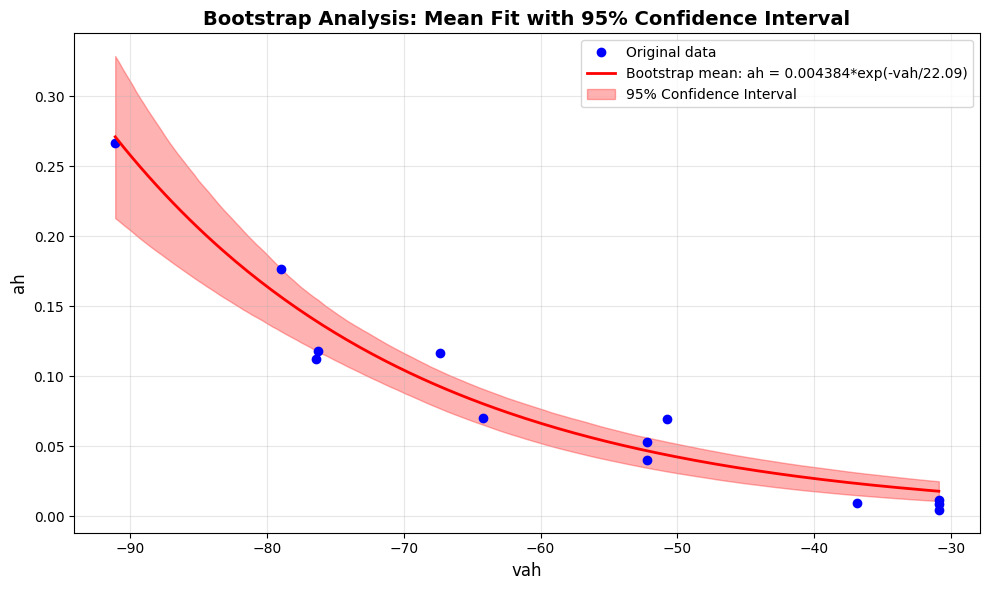

In [5]:
plt.figure(figsize=(10, 6))

# Plot original data
plt.plot(df['vah'], df['ah'], 'o', label='Original data', markersize=6, color='blue')

# Generate smooth curve for mean bootstrap fit
vah_smooth = np.linspace(df['vah'].min(), df['vah'].max(), 200)
Ah_mean = np.mean(Ah_bootstrap)
zh_mean = np.mean(zh_bootstrap)
ah_mean = exp_decay(vah_smooth, Ah_mean, zh_mean)

# Calculate confidence limits (95% CI using 2.5th and 97.5th percentiles)
ah_curves = np.array([exp_decay(vah_smooth, Ah_bootstrap[i], zh_bootstrap[i]) 
                      for i in range(len(Ah_bootstrap))])
ah_lower = np.percentile(ah_curves, 2.5, axis=0)
ah_upper = np.percentile(ah_curves, 97.5, axis=0)

# Plot mean fit and confidence interval
plt.plot(vah_smooth, ah_mean, '-', linewidth=2, color='red', 
         label=f'Bootstrap mean: ah = {Ah_mean:.6f}*exp(-vah/{zh_mean:.2f})')
plt.fill_between(vah_smooth, ah_lower, ah_upper, alpha=0.3, color='red', 
                 label='95% Confidence Interval')

plt.xlabel('vah', fontsize=12)
plt.ylabel('ah', fontsize=12)
plt.title('Bootstrap Analysis: Mean Fit with 95% Confidence Interval', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histograms of Bootstrap Parameters
Distribution of Ah and zh from bootstrap resampling.

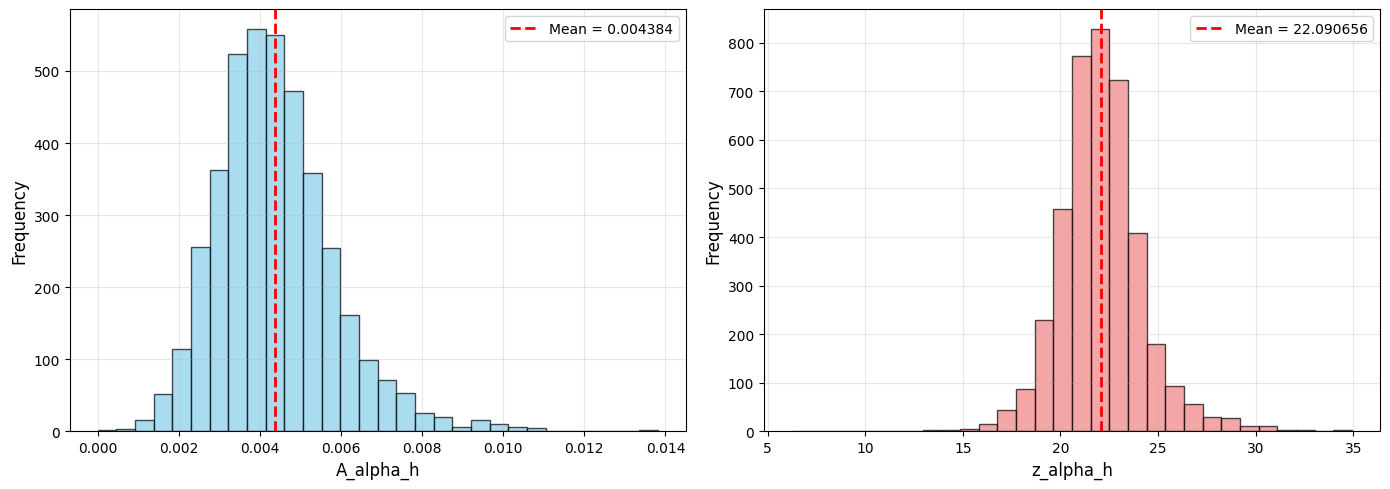

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Ah
axes[0].hist(Ah_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(np.mean(Ah_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(Ah_bootstrap):.6f}')
axes[0].set_xlabel('A_alpha_h', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Histogram of zh
axes[1].hist(zh_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(np.mean(zh_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(zh_bootstrap):.6f}')
axes[1].set_xlabel('z_alpha_h', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Parameter Correlation: Ah vs zh
Scatter plot showing the relationship between fitted Ah and zh parameters from bootstrap samples.

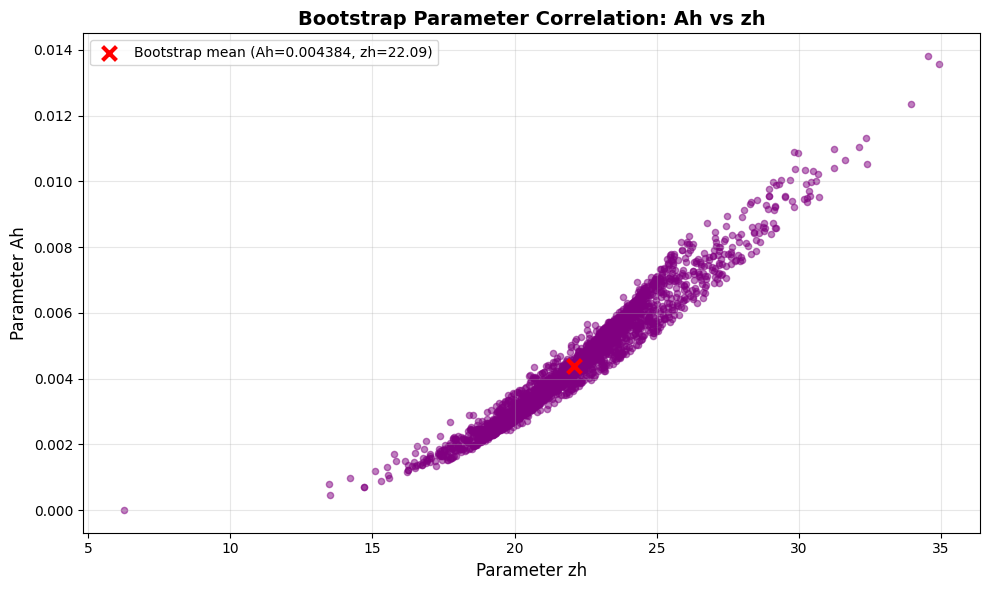


Correlation coefficient between Ah and zh: 0.9745


In [7]:
plt.figure(figsize=(10, 6))

# Calculate mean parameters
Ah_mean = np.mean(Ah_bootstrap)
zh_mean = np.mean(zh_bootstrap)

# Scatter plot of Ah vs zh
plt.scatter(zh_bootstrap, Ah_bootstrap, alpha=0.5, s=20, color='purple')
plt.scatter(zh_mean, Ah_mean, color='red', s=100, marker='x', linewidths=3, 
            label=f'Bootstrap mean (Ah={Ah_mean:.6f}, zh={zh_mean:.2f})')

plt.xlabel('Parameter zh', fontsize=12)
plt.ylabel('Parameter Ah', fontsize=12)
plt.title('Bootstrap Parameter Correlation: Ah vs zh', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
correlation = np.corrcoef(Ah_bootstrap, zh_bootstrap)[0, 1]
print(f"\nCorrelation coefficient between Ah and zh: {correlation:.4f}")